<img src="repower_2.png" width="1000">

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from matplotlib.colors import Normalize
from pandas.plotting import scatter_matrix

from utils import plot_feature_diagnostics, find_boundaries

## Data Overview

In [2]:
data = pd.read_excel('../data/Folds5x2_pp.xlsx')
display(data.head())
data.info()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


* **Shape:** $9,568$ observations × $5$ variables.
* **Data Types:** Floating-point numbers (`float64`).
* **Data Quality:** No missing values (non-null in all columns).
* **Status:** The dataset is clean, with a uniform structure.

In [3]:
print("Number of missing values: ", data.isnull().sum().sum())
print("Number of duplicates: ", len(data[data.duplicated()]))
data[data.duplicated()].head()

Number of missing values:  0
Number of duplicates:  41


,AT,V,AP,RH,PE
2184,9.54,41.17,1019.79,65.61,481.18
2421,12.11,41.17,1019.46,62.59,475.53
2577,28.84,75.60,1018.41,53.96,442.69
2896,27.54,75.60,1018.26,57.89,440.87
3314,8.07,41.17,1019.40,86.43,484.54


**Duplicates here represent repeated operating modes of the plant**

* The plant frequently operates under identical conditions (the same `AT`, `AP`, `RH`, `V`).
* Identical observations are simply normal, repeated measurements of the exact same process state.

**Repetitions carry information about the frequency of states**

* The more frequently a specific feature vector occurs, the more "weight" it should have during training:
    * the model learns better specifically in those operational modes it will encounter most often.
> Removing duplicates would artificially equalize rare and frequent modes, distorting the real data distribution.

## Summary Statistics

In [4]:
data.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


* **Feature Scale:** The spread of values differs significantly (e.g., `AP` is clustered around $1013$, while `AT` is around $20$).
    * *Implication:* Feature scaling will be required for linear models, SVMs, or neural networks.
* **Symmetry:** The mean values (`mean`) and medians (`50%`) are practically identical across all variables. This is a good sign - there is no severe skewness in the data.
* **Sanity Check:** Physical metrics are within logical bounds. No obvious anomalies or data collection errors (such as humidity `RH` $> 100\%$ or negative pressure) are observed.
* **Target Variable (`PE`):** Lies within a narrow range from $420$ to $495$ (mean $454$).

## Univariate Analysis (Feature Distributions)

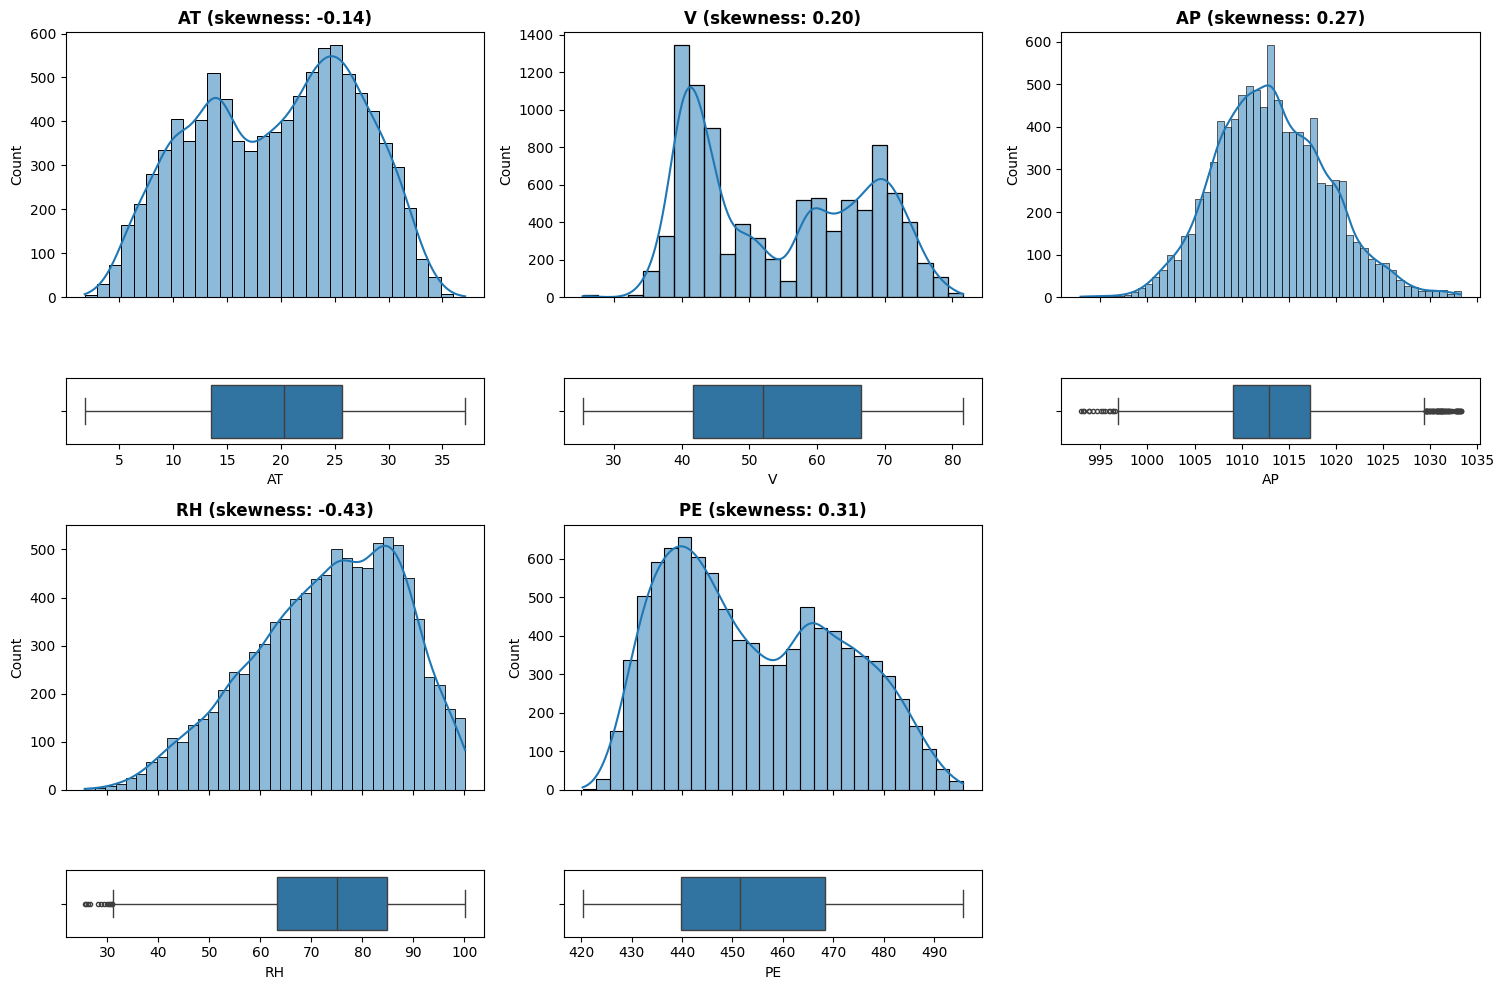

In [5]:
plot_feature_diagnostics(data, data.columns.to_list())

**`AT` (Temperature)**

* `Hist`: Bimodal, mild negative (left) skewness (`skew`: $-0.14$) -> indicates different seasons.
* `Boxplot`: No outliers based on `IQR`.

**`V` (Exhaust Vacuum)**

* `Hist`: Multimodal (several "steps") and mild positive (right) skewness (`skew`: $0.20$).
* `Boxplot`: No obvious outliers.

**`AP` (Ambient Pressure)**

* `Hist`: Close to normal, slight positive skewness (`skew`: $0.27$), narrow range.
* `Boxplot`: Visible outliers at the tails (points beyond the "whiskers").

> Consider applying winsorization (clipping extreme percentiles), e.g., $0.5–1\%$ on each side, or using the IQR rule.

**`RH` (Relative Humidity)**

* `Hist`: Right "ceiling" near $100\%$, overall negative (left) skewness (`skew`: $-0.43$).
* `Boxplot`: A few low-end outliers are present.

**`PE` (Power Output)**

* `Hist`: Bimodal distribution + mild positive skewness (`skew`: $0.31$) - reflects the combination of weather conditions.
* `Boxplot`: No outliers.

## Outlier Treatment (Winsorization)

In [6]:
# Calculate cut-off boundaries (1.5 IQR rule)
bounds = {col: find_boundaries(data, col, 1.5) for col in ['AP', 'RH']}

# Create a mask: flag rows that fall outside the boundaries in at least one of the columns
mask = False
for col in ['AP', 'RH']:
    lo, up = bounds[col]
    mask |= (data[col] < lo) | (data[col] > up)

# Filter the data: keep only the rows without outliers
df_no_outliers = data.loc[~mask].copy()

# Compare shape before and after cleaning
print(data.shape)
df_no_outliers.shape

(9568, 5)


(9468, 5)

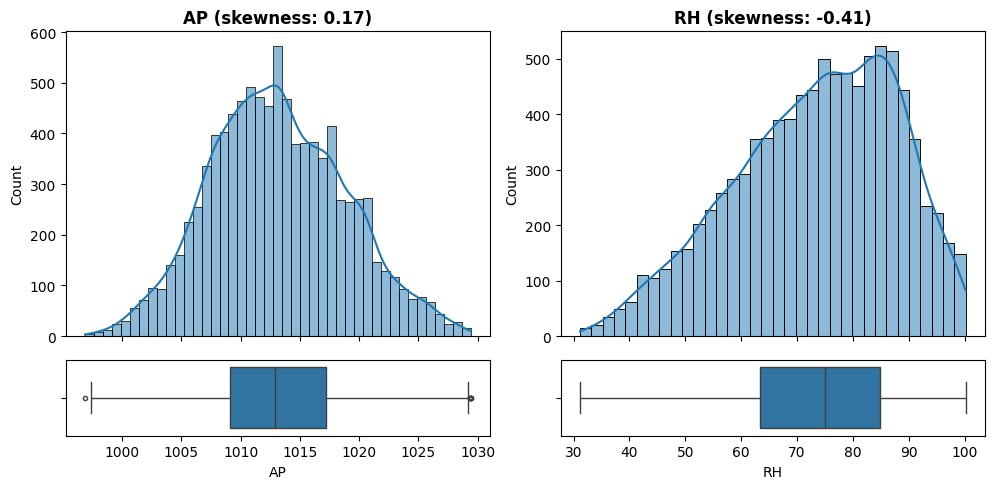

In [7]:
plot_feature_diagnostics(df_no_outliers, ['AP', 'RH'])

**`AP`**

* **Before:** slight positive skewness (`skew` $0.27$), on the `boxplot` - points beyond the whiskers.
* **After:** `skew` $0.17$ - the tail is trimmed, on the `boxplot` the extreme points are "pulled in" to the whiskers.
> Winsorization worked exactly as intended - it stabilized the tails without distorting the bulk of the data.

**`RH`**

* **Before/After:** the shape remains almost identical (`skew` $-0.43$ -> $-0.41$).|
> Winsorization barely changes the overall picture.

## Bivariate Analysis: Features vs Target

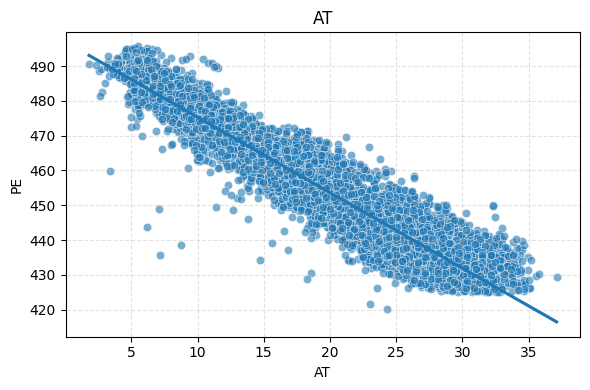

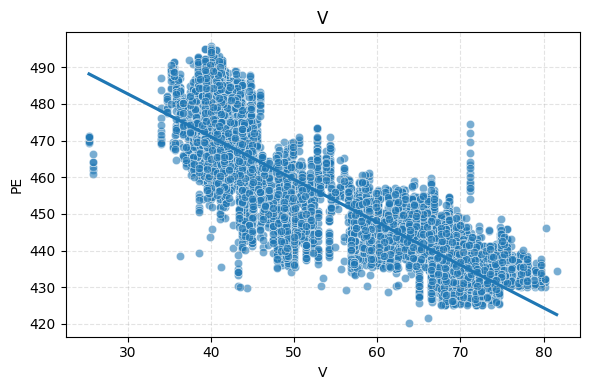

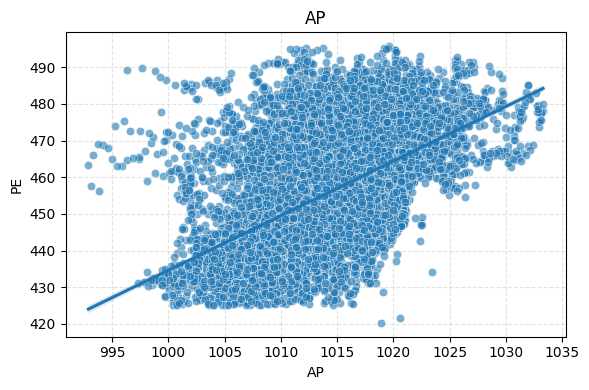

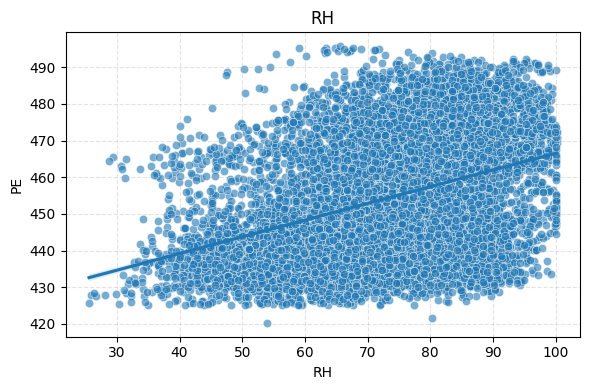

In [8]:
feature_name = data.columns.to_list()
feature_name.remove("PE")

for var in feature_name:

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.scatterplot(data=data, x=var, y='PE', alpha=0.6, ax=ax)

    sns.regplot(data=data, x=var, y='PE', ax=ax, scatter=False)

    ax.set_title(var)
    ax.grid(True, ls='--', alpha=0.35)
    fig.tight_layout()
    plt.show()

**Air Temperature**

* Strongest dependency: the higher the temperature, the lower the power output.
* Hot air is less dense -> less oxygen -> combustion efficiency decreases.
* The regression line is almost linear; the relationship is stable.

**Vacuum**

* Strong negative relationship: as the vacuum increases, power output drops.
* Clustering by operational modes is visible — representing identical states of the plant.

**Ambient Pressure**

* Positive relationship: as pressure increases, the air becomes denser, making combustion more efficient.
* The relationship is moderate but consistent.

**Air Humidity**

* Weak positive relationship.
* Humid air slightly reduces the inlet temperature -> slight increase in efficiency.
* The effect is secondary.

## Correlation Analysis

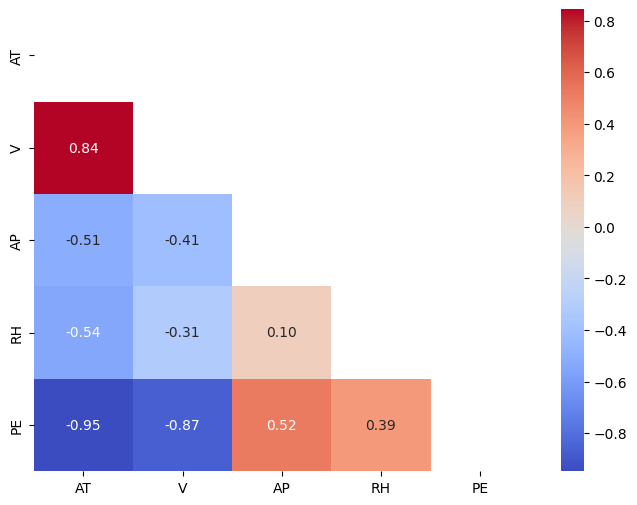

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', mask=np.triu(np.ones_like(data.corr(), dtype=bool)))
plt.show()

* `AT` - `PE` $-0.95$: **Very strong negative relationship**: the higher the ambient temperature, the lower the power output. Hot air is less dense -> less oxygen -> combustion efficiency decreases.
* `V` - `PE` $-0.87$: **Strong negative relationship**: the higher the exhaust vacuum pressure (i.e., weaker vacuum), the lower the power output. With a poor vacuum, the steam part of the turbine loses efficiency.
* `AP` - `PE` $+0.52$: **Moderate positive relationship**: the higher the ambient pressure, the higher the power output, as the air is denser and the compressor operates more efficiently.
* `RH` - `PE` $+0.39$: **Weak positive relationship**: humid air slightly cools the process, lowering the inlet temperature, and thereby slightly increasing efficiency. The effect is secondary.

**Relationships Between Features**

* `AT` - `V`: $0.84$: Strong positive relationship. As temperature rises, air density decreases, and the vacuum worsens.
* `AT` - `AP`: $-0.51$: Moderate negative relationship; as temperature rises, ambient pressure typically drops (lower air density).
* `AT` - `RH`: $-0.54$: Moderate negative relationship; the higher the temperature, the lower the relative humidity.
* `AP` - `RH`: $+0.10$: Near-zero relationship; ambient pressure and humidity are almost independent.

**Key Takeaways**

Temperature (`AT`) is the main factor.

* It explains almost all of the target's behavior.
* The $-0.95$ correlation indicates a nearly linear impact on power output.

`V` and `AT` are highly correlated ($0.84$) -> multicollinearity.

* For linear models, you should either use regularization (`Ridge`/`Lasso`),
* or drop one of the features to avoid overfitting and unstable coefficients.

`AP` and `RH` provide additional adjustments, especially `AP` ($0.52$ with `PE`).

**Physical Picture:**

* Hot -> poor vacuum -> low pressure -> less power generation.
* Cool and dense air -> high efficiency -> more power output.
* Humidity only slightly shifts the balance.

## Mutual Information

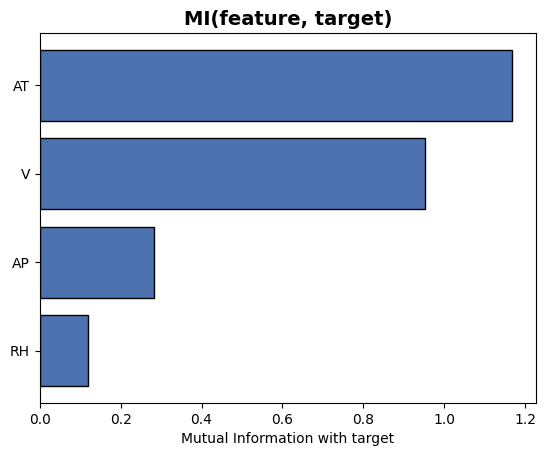

In [10]:
mi = mutual_info_regression(
    data.iloc[:, :-1],
    data.iloc[:, -1],
    random_state=0
)

mi_s = pd.Series(mi, index=data.iloc[:, :-1].columns).sort_values()

plt.barh(mi_s.index, mi_s.values, color=sns.color_palette("deep").as_hex()[0], edgecolor='black')
plt.xlabel('Mutual Information with target')
plt.title('MI(feature, target)', fontsize=14, fontweight='bold')
plt.show()

* `AT` - $1.15$: The most informative feature. Temperature explains the majority of the target variable's variance - both linearly and non-linearly.
* `RH` $0.1–0.15$: The least informative feature. Humidity has only a minor corrective effect on the plant's efficiency.

## Multivariate Analysis (Scatter Matrix)

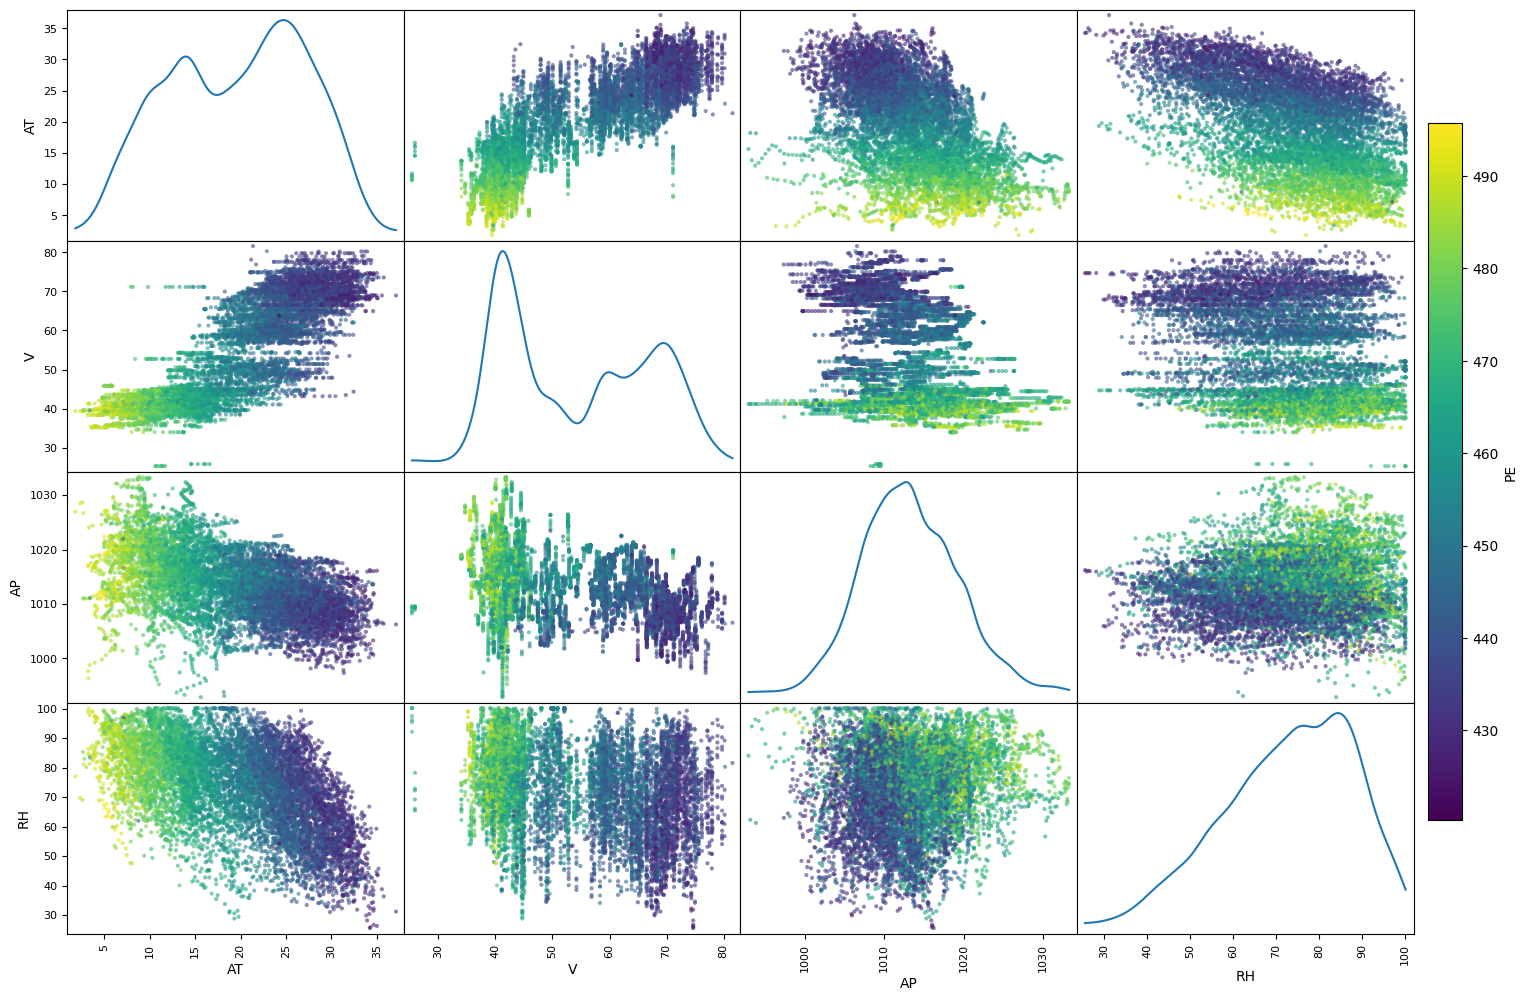

In [11]:
# Configure the colormap and map point colors to the target variable values
cmap = plt.cm.viridis
norm = Normalize(vmin=data.iloc[:,-1].min(), vmax=data.iloc[:,-1].max())
colors = cmap(norm(data.iloc[:,-1].values))

# Plot the scatter matrix: features (excluding the last column) on axes, KDE on the diagonal
axs = scatter_matrix(data.iloc[:,:-1], figsize=(18,12), diagonal='kde', color=colors, alpha=0.6)

# Add and configure the side colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=plt.gcf().axes, fraction=0.025, pad=0.01)
cbar.set_label(data.columns[-1]) 

plt.show()

**Overall Structure**
* The color scale represents the power output (`PE`):
* Purple - low values ($440 MW$)
* Yellow - high values ($480 MW$)

**Pairwise Relationships**
* **Relationship with the target (point color - `PE`):**
    * `AT` and `V` have a strong **inverse relationship** with the target variable. High target values (yellow points, $49$0) are clustered in areas of low `AT` and `V` values.
    * The impact of `AP` and `RH` on the target is visually much weaker (the point clouds are more mixed in color).

* **Multicollinearity:** A strict, direct linear relationship is visible at the intersection of `AT` and `V`. These two features almost completely duplicate each other's information.